Requisition's Generator

In [41]:
# To activate auto reloading of the modules
%load_ext autoreload

# To reload all modules before executing each cell
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import math
import numpy as np
import time
import random
import matplotlib.pyplot as plt

from req_generator import Uniform, zipf
from cache import LRU, QLRU, LFU, IRM, FairStatic, Optimal_QLRU
from monitor import Monitor

np.random.seed(0)
random.seed(0)

Parameters

In [12]:
f = 100000
t = 10000000
alpha = 0.8
c = int (f * 0.01)
initial_state = list(random.sample(range(f), c))
q = 0.001

In [13]:
num_servers = 2

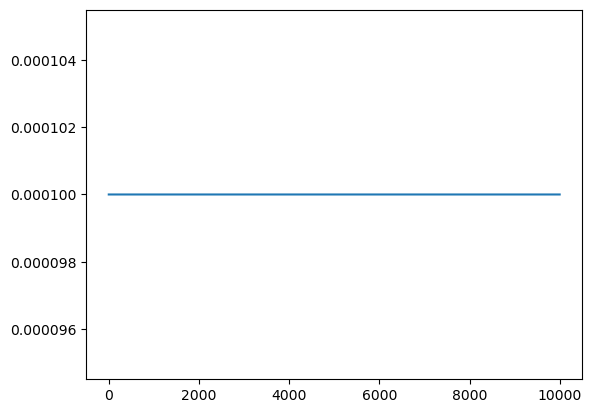

In [14]:
popularities = Uniform(f)
req = np.random.choice(f,t,p=popularities)

plt.plot([i for i in range(f)], popularities)

plt.show()

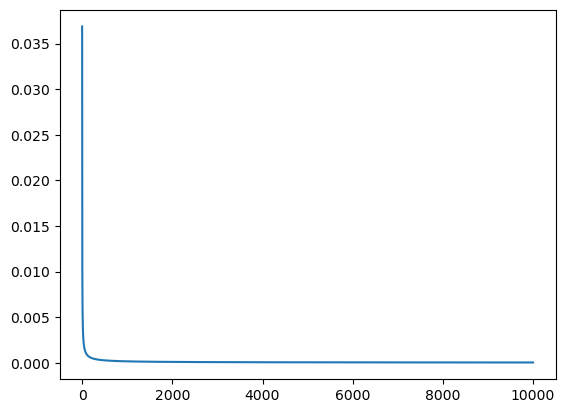

In [15]:
popularities = zipf(alpha, f)
req = np.random.choice(f, t, p=popularities)

plt.plot([i for i in range(f)], popularities)

plt.show()

Cargas Iniciais por Servidor (Sem Cache):
[0.79858736 0.20141264]
Jain's Fairness Index Inicial: 0.7371


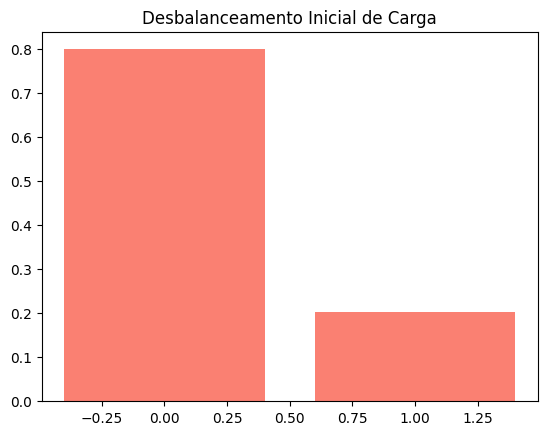

In [16]:
monitor = Monitor(num_servers, f)


fair_static_cache = FairStatic(_c=c, 
                               _popularities=popularities, 
                               _num_servers=monitor.num_servers, 
                               _file_to_server=monitor.file_to_server)

cargas_iniciais = fair_static_cache.initial_loads

print("Cargas Iniciais por Servidor (Sem Cache):")
print(cargas_iniciais)

jfi_inicial = monitor.jains_fairness_index(cargas_iniciais)
print(f"Jain's Fairness Index Inicial: {jfi_inicial:.4f}")

plt.bar(range(monitor.num_servers), cargas_iniciais, color='salmon')
plt.title("Desbalanceamento Inicial de Carga")
plt.show()

CACHE

LRU

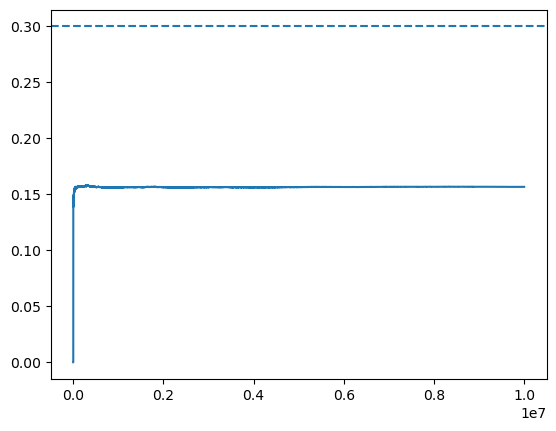

LRU's Hit Rate: 15.67%
Omega: [4360052. 4073151.]
Jain's Fairness Index: 0.9988
Angle of Vector Ω: 43.05 degrees


In [22]:


lru = LRU(initial_state, c)
monitor.plot_hit_rate(lru, req, popularities, c, "LRU")


QLRU

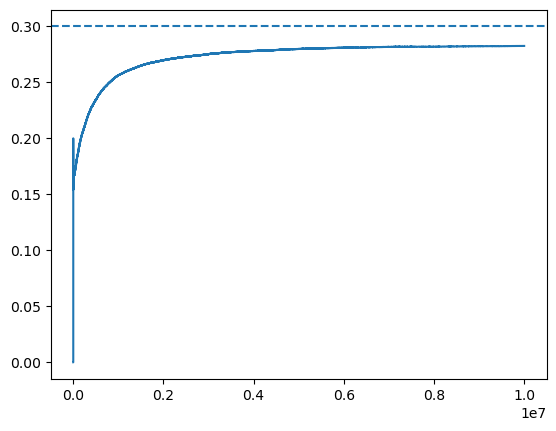

qLRU's Hit Rate: 28.25%
Omega: [3678483. 3496226.]
Jain's Fairness Index: 0.9994
Angle of Vector Ω: 43.54 degrees


In [23]:
qlru = QLRU(initial_state, c, q)
monitor.plot_hit_rate(qlru, req, popularities, c, "qLRU")

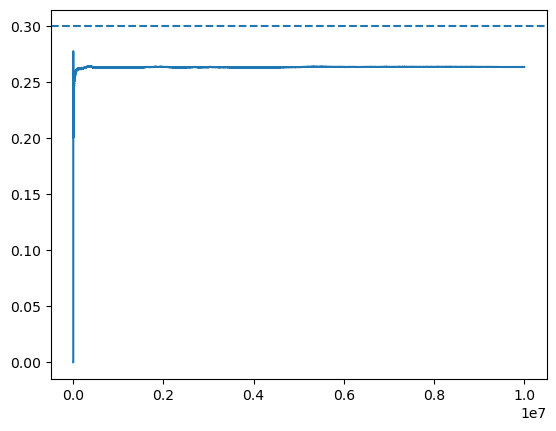

LFU's Hit Rate: 26.37%
Omega: [3707391. 3655322.]
Jain's Fairness Index: 0.9999
Angle of Vector Ω: 44.59 degrees


In [24]:
lfu = LFU(initial_state, c, f)
monitor.plot_hit_rate(lfu, req, popularities, c, "LFU")

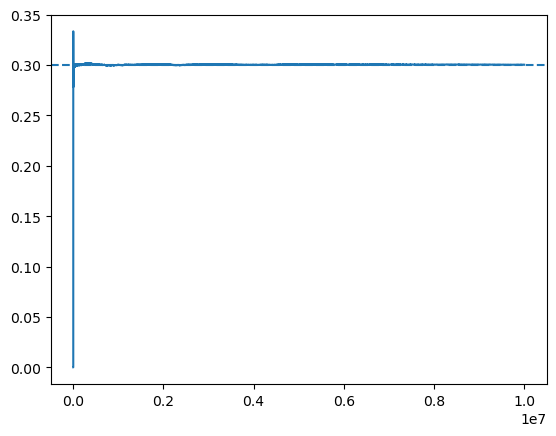

Static IRM's Hit Rate: 30.02%
Omega: [4856447. 2141467.]
Jain's Fairness Index: 0.8692
Angle of Vector Ω: 23.80 degrees


In [25]:
irm_static = IRM(c, popularities)
monitor.plot_hit_rate(irm_static, req, popularities, c, "Static IRM")

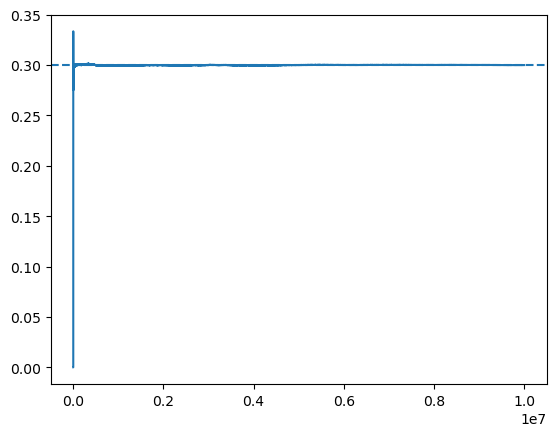

Fair Static's Hit Rate: 29.98%
Omega: [3500290. 3501292.]
Jain's Fairness Index: 1.0000
Angle of Vector Ω: 45.01 degrees


In [21]:
fair_static = FairStatic(c, popularities, num_servers, monitor.file_to_server)
monitor.plot_hit_rate(fair_static, req, popularities, c, "Fair Static")

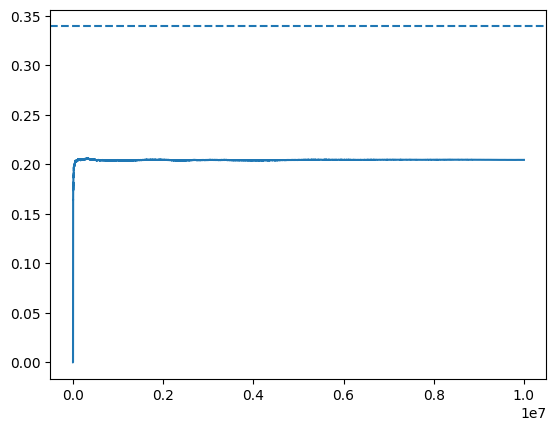

Optimal qLRU's Hit Rate: 20.46%
Omega: [5955016. 1999412.]
Jain's Fairness Index: 0.8017
Angle of Vector Ω: 18.56 degrees


In [48]:
sizes = [1] * f

beta = 2.3

optimal_qLRU = Optimal_QLRU(initial_state, c, beta, sizes, monitor.file_to_server)
monitor.plot_hit_rate(optimal_qLRU, req, popularities, c, "Optimal qLRU")